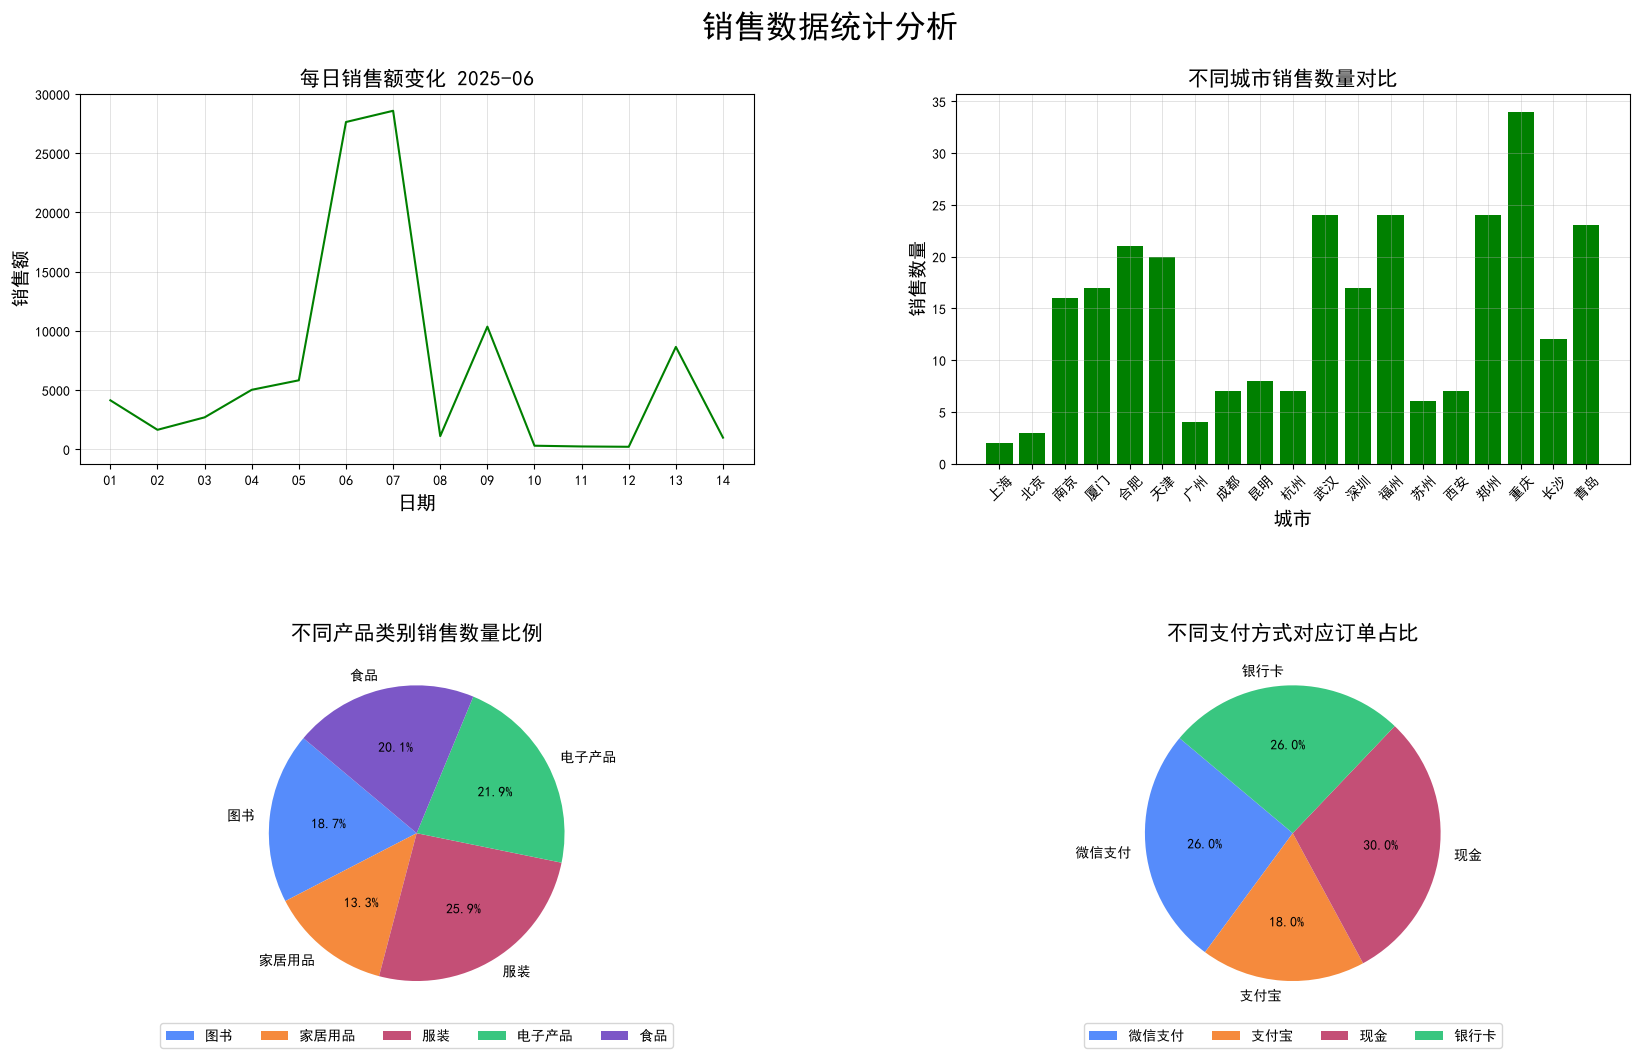

In [65]:
import pandas as pd
import matplotlib.pyplot as plt
from fontTools.diff import color
from matplotlib.axes import Axes

plt.rcParams['font.sans-serif'] = ['SimHei'] #设置中文字体

#创建子图
fig,axes = plt.subplots(nrows = 2,ncols= 2,figsize=(20,12),dpi = 100)
fig.suptitle('销售数据统计分析',fontsize = 23,x=0.5,y = 0.95) # x表示水平位置  y 表示垂直位置
plt.subplots_adjust(hspace=0.5  , wspace=0.3) # 调整子图之间的间距 hspace 纵向间距 wspace 横向间距


#获取子图
axes1 : Axes = axes[0][0]
axes2 : Axes = axes[0][1]
axes3 : Axes = axes[1][0]
axes4 : Axes = axes[1][1]

#获取数据
data = pd.read_csv('data/sales.csv',nrows=50,usecols=['产品类别','销售数量','单价','客户所在城市','支付方式','订单日期'])


# 需求一: 统计每日销售额变化
#数据清洗
data['单价'] = data['单价'].abs()
data['订单日期'] = data['订单日期'].str.replace('/','-')
data['销售额'] = data['销售数量'] * data['单价']

Sales = data.groupby('订单日期')['销售额'].sum()
Sales.index = Sales.index.str[8::]

x_date = Sales.index.tolist()
y_salse = Sales.values.tolist()

axes1.plot(x_date,y_salse,color='g')

axes1.set_title('每日销售额变化 2025-06',fontsize=15)
axes1.set_xlabel('日期',fontsize=14)
axes1.set_ylabel('销售额',fontsize=14)
axes1.grid()

# 需求二 : 不同城市销售数量对比
cities_count = data.groupby('客户所在城市')['销售数量'].sum()
x_city = cities_count.index.tolist()
y_cities_count = cities_count.values.tolist()

axes2.bar(x_city,y_cities_count,color = 'g')
axes2.set_title('不同城市销售数量对比',fontsize=15)
axes2.set_xlabel('城市',fontsize=14)
axes2.set_ylabel('销售数量',fontsize=14)
axes2.tick_params(axis='x', rotation=45)
axes2.grid()


# 需求三 : 不同产品类别销售数量比例
products_count = data.groupby('产品类别')['销售数量'].sum()
x_products = products_count.index.tolist()
y_products_count = products_count.values.tolist()

axes3.pie(y_products_count,labels=x_products,autopct='%1.1f%%',startangle=140)
axes3.set_title('不同产品类别销售数量比例',fontsize=15)
axes3.legend(loc = 'lower center',ncol=5,bbox_to_anchor=(0.5,-0.1))


# 需求四 : 不同支付方式对应订单占比
payment_count = data.groupby('支付方式')['订单日期'].count()

x_payment = payment_count.index.tolist()
y_payment_count = payment_count.values.tolist()

axes4.pie(y_payment_count,labels=x_payment,autopct='%1.1f%%',startangle=140)
axes4.set_title('不同支付方式对应订单占比',fontsize=15)
axes4.legend(loc = 'lower center',ncol=5,bbox_to_anchor=(0.5,-0.1))


plt.show()